# Modeling panel and chronological-split audit

This notebook audits the final stock-quarter panel produced by `scripts/14_build_stock_quarter_modeling_panel.py` and the fixed samples produced by `scripts/15_build_modeling_splits.py`.

It checks:

1. panel keys, input coverage, timing, and model eligibility;
2. reconciliation with the saved quarterly panel audit;
3. exact train, validation, test, and purged-quarter assignments;
4. separation of target windows across sample boundaries; and
5. sample composition, target distributions, and feature missingness.

The notebook reads saved outputs only and does not rebuild the panel or samples.

## 1. Setup and inputs

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import pyarrow.parquet as pq


project_root = Path.cwd().resolve()

while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import (
    get_modeling_splits_config,
    get_paths_config,
)
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


paths = get_paths_config()
splits = get_modeling_splits_config()
modeling_directory = paths.processed / "modeling"
panel_path = modeling_directory / "stock_quarter_panel.parquet"
panel_audit_path = modeling_directory / "stock_quarter_panel_audit.parquet"
sample_path = modeling_directory / "modeling_sample.parquet"
split_audit_path = modeling_directory / "modeling_split_audit.parquet"
ownership_directory = paths.interim / "networks" / "ownership"
security_nodes_path = ownership_directory / "security_nodes.parquet"
network_summary_path = ownership_directory / "network_summary.parquet"
market_features_path = paths.interim / "crsp" / "market_features.parquet"
targets_path = paths.interim / "crsp" / "downside_targets.parquet"

table_paths = {
    "stock_quarter_panel": panel_path,
    "stock_quarter_panel_audit": panel_audit_path,
    "modeling_sample": sample_path,
    "modeling_split_audit": split_audit_path,
}
input_paths = {
    "security_nodes": security_nodes_path,
    "network_summary": network_summary_path,
    "market_features": market_features_path,
    "downside_targets": targets_path,
}

for name, path in {**table_paths, **input_paths}.items():
    if not path.is_file():
        raise FileNotFoundError(f"Required {name} file not found: {path}")

inventory = pd.DataFrame(
    {
        "table": table_paths.keys(),
        "rows": [
            pq.ParquetFile(path).metadata.num_rows
            for path in table_paths.values()
        ],
    }
)

connection = duckdb.connect(database=":memory:")
for name, path in {**table_paths, **input_paths}.items():
    connection.read_parquet(str(path)).create_view(name)

display(inventory.style.format({"rows": "{:,}"}))

,table,rows
0,stock_quarter_panel,"206,868"
1,stock_quarter_panel_audit,52
2,modeling_sample,"184,018"
3,modeling_split_audit,3


## 2. Panel integrity and input reconciliation

The panel should preserve every ownership-network security node exactly once. Market features and targets must match on the stock-quarter key, historical features must precede the information date, and outcomes must follow it.

In [2]:
panel_check_values = connection.execute(
    '''
    WITH panel_checks AS (
        SELECT
            COUNT(*) - COUNT(DISTINCT (p.report_period, p.permno))
                AS duplicate_panel_keys,
            COUNT(*) FILTER (
                WHERE p.report_period IS NULL OR p.permno IS NULL
            ) AS missing_panel_keys,
            COUNT(*) FILTER (
                WHERE p.information_date <= p.report_period
                   OR p.feature_window_end >= p.information_date
                   OR p.target_window_start <= p.information_date
                   OR p.feature_window_end >= p.target_window_start
            ) AS timing_violations,
            COUNT(*) FILTER (
                WHERE p.model_eligible IS DISTINCT FROM
                    (p.market_feature_usable AND p.target_usable)
            ) AS incorrect_eligibility_flags,
            COUNT(*) FILTER (
                WHERE abs(
                    p.manager_holder_share
                    - p.institutional_holder_count / p.manager_count
                ) > 1e-12
            ) AS incorrect_manager_holder_shares,
            COUNT(*) FILTER (
                WHERE n.permno IS NULL OR m.permno IS NULL OR t.permno IS NULL
                   OR s.report_period IS NULL
            ) AS missing_input_matches,
            COUNT(*) FILTER (
                WHERE p.information_date != n.information_date
                   OR p.information_date != m.information_date
                   OR p.information_date != t.information_date
                   OR p.market_feature_usable
                        IS DISTINCT FROM m.market_feature_usable
                   OR p.target_usable IS DISTINCT FROM t.target_usable
                   OR p.future_max_drawdown_63d
                        IS DISTINCT FROM t.future_max_drawdown_63d
                   OR p.manager_count != s.managers
                   OR p.network_security_count != s.securities
                   OR p.ownership_edges != s.ownership_edges
            ) AS input_value_mismatches
        FROM stock_quarter_panel p
        LEFT JOIN security_nodes n USING (report_period, permno)
        LEFT JOIN market_features m USING (report_period, permno)
        LEFT JOIN downside_targets t USING (report_period, permno)
        LEFT JOIN network_summary s USING (report_period)
    ),
    coverage_checks AS (
        SELECT
            COUNT(*) FILTER (WHERE p.permno IS NULL) AS nodes_without_panel_rows,
            COUNT(*) FILTER (WHERE n.permno IS NULL) AS panel_rows_without_nodes
        FROM (SELECT report_period, permno FROM security_nodes) n
        FULL JOIN (SELECT report_period, permno FROM stock_quarter_panel) p
            USING (report_period, permno)
    )
    SELECT * FROM panel_checks CROSS JOIN coverage_checks
    '''
).fetchdf().iloc[0]

panel_checks = pd.DataFrame(
    {
        "check": panel_check_values.index.str.replace("_", " "),
        "violations": panel_check_values.values,
    }
)

display(panel_checks.style.format({"violations": "{:,}"}))
print()
print(f"Total panel-integrity violations: {panel_checks['violations'].sum():,}")

,check,violations
0,duplicate panel keys,0
1,missing panel keys,0
2,timing violations,0
3,incorrect eligibility flags,0
4,incorrect manager holder shares,0
5,missing input matches,0
6,input value mismatches,0
7,nodes without panel rows,0
8,panel rows without nodes,0



Total panel-integrity violations: 0


## 3. Quarterly panel audit

The saved Script 14 audit is independently reproduced from the final panel.

In [3]:
panel_audit_reconciliation = connection.execute(
    '''
    WITH calculated AS (
        SELECT
            PERIODOFREPORT, report_period, information_date,
            COUNT(*) AS security_periods,
            COUNT(*) FILTER (WHERE market_feature_usable)
                AS market_feature_usable_periods,
            COUNT(*) FILTER (WHERE target_usable) AS target_usable_periods,
            COUNT(*) FILTER (WHERE model_eligible) AS model_eligible_periods,
            AVG(CAST(model_eligible AS DOUBLE)) AS model_eligible_share,
            MEDIAN(future_max_drawdown_63d) FILTER (WHERE model_eligible)
                AS median_future_max_drawdown_63d
        FROM stock_quarter_panel
        GROUP BY PERIODOFREPORT, report_period, information_date
    )
    SELECT
        (SELECT COUNT(*) - COUNT(DISTINCT report_period)
         FROM stock_quarter_panel_audit) AS duplicate_audit_quarters,
        COUNT(*) FILTER (WHERE c.report_period IS NULL) AS audits_without_rows,
        COUNT(*) FILTER (WHERE a.report_period IS NULL) AS quarters_without_audits,
        COUNT(*) FILTER (
            WHERE a.PERIODOFREPORT != c.PERIODOFREPORT
               OR a.information_date != c.information_date
               OR a.security_periods != c.security_periods
               OR a.market_feature_usable_periods
                    != c.market_feature_usable_periods
               OR a.target_usable_periods != c.target_usable_periods
               OR a.model_eligible_periods != c.model_eligible_periods
               OR abs(a.model_eligible_share - c.model_eligible_share) > 1e-12
               OR a.median_future_max_drawdown_63d
                    IS DISTINCT FROM c.median_future_max_drawdown_63d
        ) AS quarterly_statistic_mismatches
    FROM stock_quarter_panel_audit a
    FULL JOIN calculated c USING (report_period)
    '''
).fetchdf().T.reset_index()
panel_audit_reconciliation.columns = ["check", "violations"]

panel_summary = connection.execute(
    '''
    SELECT
        COUNT(*) AS stock_quarters,
        COUNT(DISTINCT permno) AS securities,
        COUNT(DISTINCT report_period) AS quarters,
        COUNT(*) FILTER (WHERE model_eligible) AS eligible_stock_quarters,
        AVG(CAST(model_eligible AS DOUBLE)) AS eligible_share
    FROM stock_quarter_panel
    '''
).fetchdf()

display(panel_audit_reconciliation.style.format({"violations": "{:,}"}))
display(panel_summary.style.format({
    "stock_quarters": "{:,}",
    "securities": "{:,}",
    "quarters": "{:,}",
    "eligible_stock_quarters": "{:,}",
    "eligible_share": "{:.2%}",
}))

,check,violations
0,duplicate_audit_quarters,0
1,audits_without_rows,0
2,quarters_without_audits,0
3,quarterly_statistic_mismatches,0


,stock_quarters,securities,quarters,eligible_stock_quarters,eligible_share
0,"206,868","7,232",52,"192,109",92.87%


## 4. Chronological splits and purging

The modeling sample should contain only eligible observations inside the fixed train, validation, and test ranges. The omitted quarter between adjacent samples ensures that every earlier target is fully observed before the next sample begins.

In [4]:
train_start = splits.train_start_date.isoformat()
train_end = splits.train_end_date.isoformat()
validation_start = splits.validation_start_date.isoformat()
validation_end = splits.validation_end_date.isoformat()
test_start = splits.test_start_date.isoformat()
test_end = splits.test_end_date.isoformat()

split_check_values = connection.execute(
    f'''
    WITH sample_checks AS (
        SELECT
            COUNT(*) - COUNT(DISTINCT (report_period, permno))
                AS duplicate_sample_keys,
            COUNT(*) FILTER (WHERE NOT model_eligible)
                AS ineligible_sample_rows,
            COUNT(*) FILTER (
                WHERE CASE
                    WHEN report_period BETWEEN DATE '{train_start}' AND DATE '{train_end}'
                        THEN 'train'
                    WHEN report_period BETWEEN DATE '{validation_start}' AND DATE '{validation_end}'
                        THEN 'validation'
                    WHEN report_period BETWEEN DATE '{test_start}' AND DATE '{test_end}'
                        THEN 'test'
                END IS DISTINCT FROM sample_split
            ) AS incorrect_split_labels
        FROM modeling_sample
    ),
    expected AS (
        SELECT report_period, permno
        FROM stock_quarter_panel
        WHERE model_eligible
          AND (
              report_period BETWEEN DATE '{train_start}' AND DATE '{train_end}'
              OR report_period BETWEEN DATE '{validation_start}' AND DATE '{validation_end}'
              OR report_period BETWEEN DATE '{test_start}' AND DATE '{test_end}'
          )
    ),
    actual AS (
        SELECT report_period, permno FROM modeling_sample
    ),
    coverage_checks AS (
        SELECT
            COUNT(*) FILTER (WHERE a.permno IS NULL)
                AS expected_rows_missing_from_sample,
            COUNT(*) FILTER (WHERE e.permno IS NULL)
                AS unexpected_rows_in_sample
        FROM expected e FULL JOIN actual a USING (report_period, permno)
    ),
    chronology_checks AS (
        SELECT
            CAST(
                MAX(target_window_end) FILTER (WHERE sample_split = 'train')
                >= MIN(information_date) FILTER (WHERE sample_split = 'validation')
                AS INTEGER
            ) AS train_validation_target_overlap,
            CAST(
                MAX(target_window_end) FILTER (WHERE sample_split = 'validation')
                >= MIN(information_date) FILTER (WHERE sample_split = 'test')
                AS INTEGER
            ) AS validation_test_target_overlap
        FROM modeling_sample
    ),
    calculated_audit AS (
        SELECT
            CASE sample_split WHEN 'train' THEN 1
                WHEN 'validation' THEN 2 WHEN 'test' THEN 3 END AS split_order,
            sample_split,
            MIN(report_period) AS report_period_start,
            MAX(report_period) AS report_period_end,
            MIN(information_date) AS information_date_start,
            MAX(information_date) AS information_date_end,
            MAX(target_window_end) AS latest_target_window_end,
            COUNT(DISTINCT report_period) AS quarters,
            COUNT(*) AS security_periods,
            COUNT(DISTINCT permno) AS securities
        FROM modeling_sample
        GROUP BY sample_split
    ),
    audit_checks AS (
        SELECT
            COUNT(*) - COUNT(DISTINCT a.sample_split)
                AS duplicate_split_audit_rows,
            COUNT(*) FILTER (
                WHERE c.sample_split IS NULL OR a.sample_split IS NULL
                   OR a.split_order != c.split_order
                   OR a.report_period_start != c.report_period_start
                   OR a.report_period_end != c.report_period_end
                   OR a.information_date_start != c.information_date_start
                   OR a.information_date_end != c.information_date_end
                   OR a.latest_target_window_end != c.latest_target_window_end
                   OR a.quarters != c.quarters
                   OR a.security_periods != c.security_periods
                   OR a.securities != c.securities
            ) AS split_audit_mismatches
        FROM modeling_split_audit a
        FULL JOIN calculated_audit c USING (sample_split)
    )
    SELECT *
    FROM sample_checks
    CROSS JOIN coverage_checks
    CROSS JOIN chronology_checks
    CROSS JOIN audit_checks
    '''
).fetchdf().iloc[0]

split_checks = pd.DataFrame(
    {
        "check": split_check_values.index.str.replace("_", " "),
        "violations": split_check_values.values,
    }
)

purged_quarters = connection.execute(
    f'''
    SELECT report_period, COUNT(*) AS eligible_stock_quarters
    FROM stock_quarter_panel
    WHERE model_eligible
      AND report_period BETWEEN DATE '{train_start}' AND DATE '{test_end}'
      AND NOT (
          report_period BETWEEN DATE '{train_start}' AND DATE '{train_end}'
          OR report_period BETWEEN DATE '{validation_start}' AND DATE '{validation_end}'
          OR report_period BETWEEN DATE '{test_start}' AND DATE '{test_end}'
      )
    GROUP BY report_period
    ORDER BY report_period
    '''
).fetchdf()

display(split_checks.style.format({"violations": "{:,}"}))
print()
print(f"Total split-integrity violations: {split_checks['violations'].sum():,}")
display(purged_quarters.style.format({"eligible_stock_quarters": "{:,}"}))

,check,violations
0,duplicate sample keys,0
1,ineligible sample rows,0
2,incorrect split labels,0
3,expected rows missing from sample,0
4,unexpected rows in sample,0
5,train validation target overlap,0
6,validation test target overlap,0
7,duplicate split audit rows,0
8,split audit mismatches,0



Total split-integrity violations: 0


,report_period,eligible_stock_quarters
0,2021-12-31 00:00:00,"4,042"
1,2023-12-31 00:00:00,"4,049"


## 5. Sample composition and target shift

Chronological samples need not have identical target distributions. The comparison documents temporal distribution shift without using validation or test outcomes to alter the fixed split boundaries.

In [5]:
split_summary = connection.execute(
    '''
    SELECT
        split_order, sample_split, report_period_start, report_period_end,
        information_date_start, information_date_end, latest_target_window_end,
        quarters, security_periods, securities
    FROM modeling_split_audit
    ORDER BY split_order
    '''
).fetchdf()

target_by_split = connection.execute(
    '''
    SELECT
        sample_split,
        COUNT(*) AS stock_quarters,
        AVG(future_max_drawdown_63d) AS mean_drawdown,
        QUANTILE_CONT(future_max_drawdown_63d, 0.10) AS p10_drawdown,
        MEDIAN(future_max_drawdown_63d) AS median_drawdown,
        QUANTILE_CONT(future_max_drawdown_63d, 0.90) AS p90_drawdown
    FROM modeling_sample
    GROUP BY sample_split
    ORDER BY CASE sample_split
        WHEN 'train' THEN 1 WHEN 'validation' THEN 2 WHEN 'test' THEN 3 END
    '''
).fetchdf()

display(split_summary.style.format({
    "quarters": "{:,}",
    "security_periods": "{:,}",
    "securities": "{:,}",
}))
display(target_by_split.style.format({
    "stock_quarters": "{:,}",
    "mean_drawdown": "{:.2%}",
    "p10_drawdown": "{:.2%}",
    "median_drawdown": "{:.2%}",
    "p90_drawdown": "{:.2%}",
}))

,split_order,sample_split,report_period_start,report_period_end,information_date_start,information_date_end,latest_target_window_end,quarters,security_periods,securities
0,1,train,2013-06-30 00:00:00,2021-09-30 00:00:00,2013-08-14 00:00:00,2021-11-15 00:00:00,2022-02-15 00:00:00,34,"123,791","5,701"
1,2,validation,2022-03-31 00:00:00,2023-09-30 00:00:00,2022-05-16 00:00:00,2023-11-14 00:00:00,2024-02-15 00:00:00,7,"29,716","4,733"
2,3,test,2024-03-31 00:00:00,2025-12-31 00:00:00,2024-05-15 00:00:00,2026-02-17 00:00:00,2026-05-18 00:00:00,8,"30,511","4,255"


,sample_split,stock_quarters,mean_drawdown,p10_drawdown,median_drawdown,p90_drawdown
0,train,"123,791",19.87%,5.92%,15.30%,40.89%
1,validation,"29,716",24.91%,6.80%,20.30%,50.38%
2,test,"30,511",24.92%,7.69%,20.04%,49.19%


## 6. Target distribution across splits

The boxplot summarizes the full target distribution in each chronological sample. Individual outlier markers are hidden only to keep the figure readable; all observations remain included when the boxplot statistics are calculated.

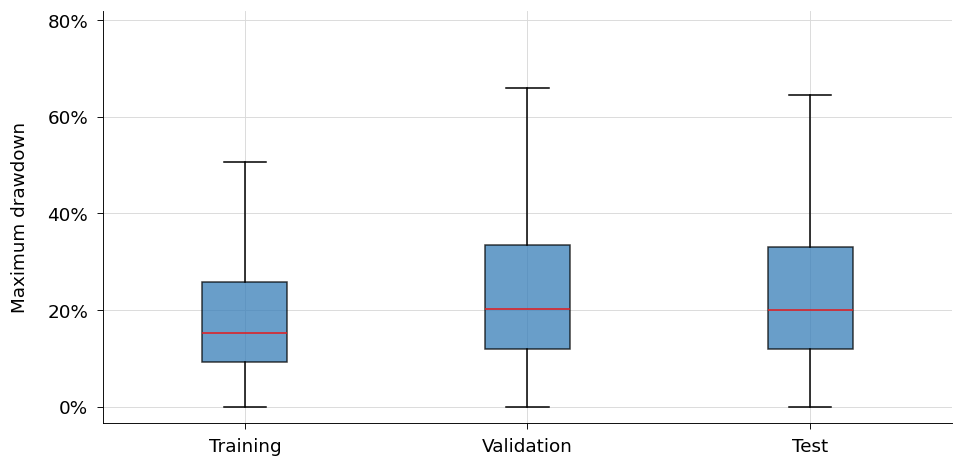

In [6]:
import numpy as np
from matplotlib.ticker import PercentFormatter

split_order = ["train", "validation", "test"]
split_labels = ["Training", "Validation", "Test"]
target_plot = connection.execute(
    '''
    SELECT sample_split, future_max_drawdown_63d
    FROM modeling_sample
    '''
).fetchdf()
target_values = [
    target_plot.loc[
        target_plot["sample_split"] == split,
        "future_max_drawdown_63d",
    ]
    for split in split_order
]

set_matplotlib_style()
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
boxplot = axis.boxplot(
    target_values,
    tick_labels=split_labels,
    showfliers=False,
    patch_artist=True,
)

for box in boxplot["boxes"]:
    box.set_facecolor(COLOR_PALETTE[0])
    box.set_alpha(0.75)

axis.set_yticks(np.arange(0.0, 0.9, 0.2))
axis.set_ylim(top=0.82)

#axis.set_title("Forward 63-day maximum drawdown by sample")
axis.set_xlabel("")
axis.set_ylabel("Maximum drawdown")
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "01_08_target_distribution_boxplot.pdf")
plt.show()

## 7. Predictor missingness

Market and level ownership predictors should be complete in the modeling sample. Ownership-change predictors are expected to be missing when a stock lacks a consecutive-quarter predecessor; these values are imputed later using fitting-sample information only.

In [7]:
predictor_columns = [
    "market_cap_usd",
    "average_daily_dollar_volume_63d",
    "return_21d",
    "momentum_252_21d",
    "volatility_63d",
    "downside_volatility_63d",
    "market_beta_252d",
    "maximum_drawdown_252d",
    "negative_return_share_63d",
    "institutional_holder_count",
    "total_reported_value_usd",
    "reported_ownership_hhi",
    "top_five_reported_ownership_share",
    "mean_owner_portfolio_weight",
    "maximum_owner_portfolio_weight",
    "manager_holder_share",
    "institutional_holder_count_change_percent",
    "total_reported_value_change_percent",
    "reported_ownership_hhi_change",
    "top_five_reported_ownership_share_change",
]
missing_expressions = ",\n".join(
    f"AVG(CAST({column} IS NULL AS DOUBLE)) AS {column}"
    for column in predictor_columns
)
missingness_wide = connection.execute(
    f'''
    SELECT sample_split, {missing_expressions}
    FROM modeling_sample
    GROUP BY sample_split
    '''
).fetchdf()
missingness = (
    missingness_wide.melt(
        id_vars="sample_split",
        var_name="predictor",
        value_name="missing_share",
    )
    .pivot(index="predictor", columns="sample_split", values="missing_share")
    .reindex(columns=["train", "validation", "test"])
)
nonzero_missingness = missingness.loc[missingness.max(axis=1) > 0]

print(
    "Fully observed predictors: "
    f"{len(predictor_columns) - len(nonzero_missingness)} of "
    f"{len(predictor_columns)}"
)
display(nonzero_missingness.style.format("{:.2%}"))

connection.close()

Fully observed predictors: 16 of 20


sample_split,train,validation,test
predictor,,,
institutional_holder_count_change_percent,3.02%,0.16%,0.15%
reported_ownership_hhi_change,3.02%,0.16%,0.15%
top_five_reported_ownership_share_change,3.02%,0.16%,0.15%
total_reported_value_change_percent,3.02%,0.16%,0.15%


## 8. Interpretation

- **The final panel preserves and correctly combines its inputs.** It contains 206,868 unique stock-quarter rows for 7,232 securities over 52 quarters, exactly matching the ownership-network security nodes. Ownership, market, target, and quarter-level network fields reconcile with their source tables, and every timing and eligibility check returns zero violations.
- **The joint eligibility rule retains most observations.** A total of 192,109 stock-quarters, or 92.87% of the panel, have both usable historical market features and a usable future target. Ineligible observations remain in the full panel with explicit component flags.
- **The chronological samples follow the frozen design.** The modeling sample contains 123,791 training observations across 34 quarters, 29,716 validation observations across 7 quarters, and 30,511 test observations across 8 quarters. Every row is eligible and assigned to exactly the configured period.
- **Purging removes the intended boundary quarters.** The 4,042 eligible observations from 2021 Q4 and 4,049 from 2023 Q4 are excluded. The latest training target ends on 15 February 2022, before validation information begins on 16 May 2022; the latest validation target ends on 15 February 2024, before test information begins on 15 May 2024. Thus outcomes from an earlier sample cannot extend into the next sample's information set.
- **The target distribution shifts through time.** Median maximum drawdown increases from 15.30% in training to 20.30% in validation and 20.04% in testing; the corresponding 90th percentile rises from 40.89% to approximately 50%. This is a genuine chronological distribution shift that the out-of-sample evaluation must confront, not a reason to revise the fixed boundaries.
- **Missingness is limited to lagged ownership changes.** Sixteen of the twenty frozen market and conventional ownership predictors are fully observed. The four change predictors are missing for 3.02% of training rows and about 0.15% of validation and test rows, as expected when a security lacks a consecutive-quarter predecessor. These values must be imputed using parameters learned from the fitting sample only.

Scripts 14 and 15 therefore produce a coherent, leakage-free modeling sample. The data-construction stage is complete; subsequent preprocessing and model fitting must preserve these chronological boundaries.